# Revisão bibliográfica — reunião de acompanhamento

Notebook de consolidação do estado da revisão em 08/09/2026. A visão completa combina as 52 referências do pré-projeto com as oito fontes incorporadas na busca complementar.


In [11]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
BASE = Path('../..')


In [12]:
csv_path = BASE / 'fichamentos/dados/inventario-completo.csv'
json_path = BASE / 'fichamentos/dados/inventario-completo.json'
df = pd.read_csv(csv_path)
inventory_json = json.loads(json_path.read_text())
assert len(df) == len(inventory_json)
assert set(df['chave']) == {row['chave'] for row in inventory_json}
print(f'Referências no inventário completo: {len(df)}')
print(df['origem_selecao'].value_counts())
print(f'Fichas LaTeX (excluindo modelo): {len(list((BASE / 'fichamentos/fichas').glob('*.tex'))) - 1}')


Referências no inventário completo: 60
origem_selecao
pré-projeto                           52
busca complementar pós-pré-projeto     8
Name: count, dtype: int64
Fichas LaTeX (excluindo modelo): 53


## Cobertura do inventário original

,status,quantidade
0,Fichado — consulta focal/parcial,45
1,Incorporado — ficha 46–53,8
2,Pendente — acesso ou versão,7


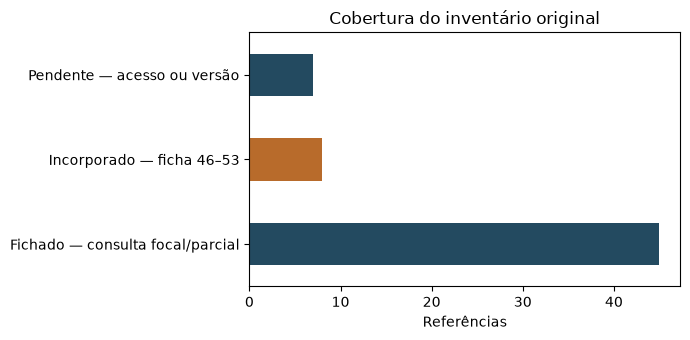

In [13]:
status = df['status'].value_counts().rename_axis('status').reset_index(name='quantidade')
display(status)
fig, ax = plt.subplots(figsize=(7, 3.5))
status.plot.barh(x='status', y='quantidade', ax=ax, legend=False, color=['#234A60', '#B86B2B'])
ax.set_xlabel('Referências'); ax.set_ylabel(''); ax.set_title('Cobertura do inventário original')
plt.tight_layout(); plt.show()


In [14]:
display(pd.crosstab(df['lote'], df['status']))
display(df[df['status'].str.startswith('Pendente')][['chave','titulo','observacao']])


status,Fichado — consulta focal/parcial,Incorporado — ficha 46–53,Pendente — acesso ou versão
lote,,,
1 — avaliação de RAG e benchmarks,11,8,0
2 — contexto legislativo e aplicações parlamentares,9,0,3
3 — recuperação da informação e engenharia de busca,5,0,0
4 — metodologia de pesquisa e desenho do estudo,1,0,4
"5 — fundamentos, revisões e riscos",19,0,0


,chave,titulo,observacao
1,peffersEtAl2007dsrm,A Design Science Research Methodology for Info...,Texto integral não obtido: cópia universitária...
3,geunis2023parliamentaryMonitoring,Parliamentary Monitoring Organizations: Partne...,Identidade/versão pendente: URL atualmente apr...
11,deAlmeidaSantos2025aiGovernance,Artificial intelligence governance: Understand...,Texto integral não localizado; acesso disponív...
22,matoshiEtAl2025parliamentRag,Transforming Digital Access in Parliament: Top...,Repositório institucional indica acesso restri...
35,gil2022projetosPesquisa,Como elaborar projetos de pesquisa,Livro não disponível localmente: necessária 7ª...
36,lakatosMarconi2021metodologia,Fundamentos de metodologia cient{\'i}fica,Livro não disponível localmente: necessária 9ª...
37,creswellPlanoClark2018mixedMethods,Designing and Conducting Mixed Methods Research,Livro não disponível localmente: necessária 3ª...


## Perfil temático e documental

,tipo,quantidade
0,inproceedings,25
1,online,13
2,article,11
3,report,7
4,book,4


,ano,quantidade
0,2004,1
1,2007,1
2,2008,1
3,2016,1
4,2017,1
5,2018,1
6,2019,1
7,2020,6
8,2021,5
9,2022,3


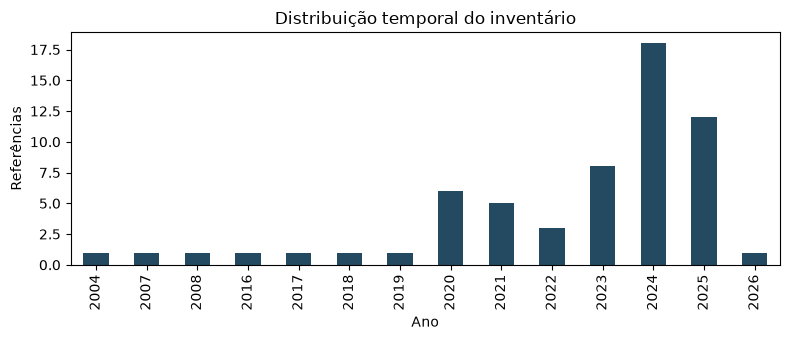

In [15]:
display(df['tipo'].value_counts().rename_axis('tipo').reset_index(name='quantidade'))
display(df.groupby('ano').size().rename('quantidade').reset_index())
fig, ax = plt.subplots(figsize=(8, 3.5))
df.groupby('ano').size().plot.bar(ax=ax, color='#234A60')
ax.set_xlabel('Ano'); ax.set_ylabel('Referências'); ax.set_title('Distribuição temporal do inventário')
plt.tight_layout(); plt.show()


## Subcategorias temáticas

O lote 5 é detalhado por subcategorias; os demais lotes também recebem uma subcategoria para permitir uma leitura mais precisa do conjunto.


In [20]:
sub = df['subcategoria_tematica'].value_counts().rename_axis('subcategoria').reset_index(name='quantidade')
display(sub)
display(df[df['lote'].eq('5 — fundamentos, revisões e riscos')][['titulo','subcategoria_tematica']])


,subcategoria,quantidade
0,surveys e revisões,9
1,métricas e avaliação automatizada,5
2,arquiteturas e modelos,5
3,governança e diretrizes institucionais,4
4,aplicações RAG jurídico-políticas,4
5,benchmarks de grounding e alucinação,4
6,corpus e discurso parlamentar,3
7,aplicações parlamentares e legislativas,3
8,recuperação neural,3
9,Design Science Research,2


,titulo,subcategoria_tematica
7,Large Language Models: A Survey,surveys e revisões
8,Survey and Analysis of Hallucinations in Large...,surveys e revisões
9,Large Legal Fictions: Profiling Legal Hallucin...,alucinação e avaliação geral
13,Retrieval-Augmented Generation for Large Langu...,surveys e revisões
14,A Comprehensive Survey of Retrieval-Augmented ...,surveys e revisões
31,Attention Is All You Need,arquiteturas e modelos
32,Modular RAG: Transforming RAG Systems into LEG...,surveys e revisões
33,When Text Embedding Meets Large Language Model...,surveys e revisões
38,Language Models are Few-Shot Learners,arquiteturas e modelos
39,A Survey of Large Language Models,surveys e revisões


## Fontes incorporadas além do inventário original

In [17]:
adicionais = pd.DataFrame([
 ('Trautmann et al. (2024)', 'groundedness jurídico'),
 ('Niu et al. (2024)', 'RAGTruth e alucinação'),
 ('Zhang et al. (2024)', 'suporte de citações'),
 ('Sorodoc et al. (2025)', 'GaRAGe, grounding e deflexão'),
 ('Reuter et al. (2025)', 'erro de recuperação no nível do documento'),
 ('Muller et al. (2025)', 'meta-avaliação de juízes'),
 ('Salemi e Zamani (2024)', 'utilidade downstream da recuperação'),
 ('Yu et al. (2024)', 'survey de avaliação de RAG')
], columns=['fonte','função_no_protocolo'])
display(adicionais)


,fonte,função_no_protocolo
0,Trautmann et al. (2024),groundedness jurídico
1,Niu et al. (2024),RAGTruth e alucinação
2,Zhang et al. (2024),suporte de citações
3,Sorodoc et al. (2025),"GaRAGe, grounding e deflexão"
4,Reuter et al. (2025),erro de recuperação no nível do documento
5,Muller et al. (2025),meta-avaliação de juízes
6,Salemi e Zamani (2024),utilidade downstream da recuperação
7,Yu et al. (2024),survey de avaliação de RAG


## Decisões propostas para a reunião

1. Confirmar com o orientador que a contribuição da dissertação está em integrar, em um único protocolo aplicado a discursos parlamentares brasileiros, a avaliação da recuperação, da geração, da verificabilidade das fontes, do reconhecimento de insuficiência documental e da validação humana.
2. Confirmar com o orientador se a rubrica de pontuação de 0 a 2 e as cinco dimensões — correção factual, aderência ao contexto recuperado, suporte e precisão das citações, completude proporcional e reconhecimento de insuficiência documental — são adequadas ao protocolo.
3. Definir o tamanho da bateria de perguntas e da amostra humana.
4. Decidir se Peffers, Gil, Lakatos e Creswell serão recuperados ou substituídos.
5. Autorizar o início do piloto.